<a href="https://colab.research.google.com/github/merasifa/PCVK/blob/main/WEEK5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum Pengolahan Citra Digital - Week 5

**Nama:** Tiara Mera Sifa <br>
**NIM:** 2141720247 <br>
**Kelas:** TI-3B <br>


TUGAS PRAKTIKUM

1. Buat Gamma Correction sesuai dengan petunjuk berikut
Percobaan ini akan meminta anda membuat Gamma Correction. Pada percobaan ini, nilai
Gamma akan diset dengan meminta masukan dari pengguna. Berikut adalah kode untuk
meminta masukan nilai dari pengguna. Lanjutkan kode tersebut dengan membuat image
dengan gamma correction sesuai rumus yang telah diberikan.

In [12]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Gamma Correction pada citra 
----------------------------
Masukkan nilai Gamma: 3


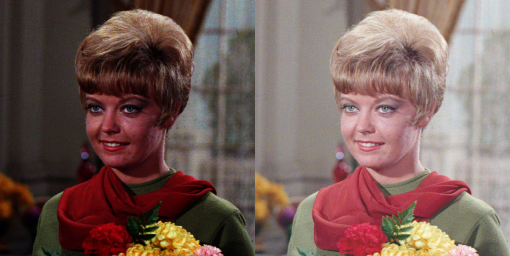

In [17]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Import library
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

print('Gamma Correction pada citra ')
print('----------------------------')

try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')
    gamma = 1.0

# Baca gambar dari Google Drive
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/perempuan.png')

# Pastikan gambar terbaca
if img is None:
    print("⚠️ Gambar tidak ditemukan! Cek kembali path-nya.")
else:
    # Konversi ke float dan normalisasi ke rentang [0, 1]
    img_norm = img.astype(np.float32) / 255.0

    # Terapkan gamma correction (rumus: I' = 255 * (I/255)^(1/gamma))
    gamma_img = np.power(img_norm, 1.0 / gamma) * 255

    # Kembalikan ke tipe uint8 dan rentang [0,255]
    gamma_img = np.clip(gamma_img, 0, 255).astype(np.uint8)

    # Gabungkan hasil (asli + hasil koreksi)
    final = cv2.hconcat([img, gamma_img])

    # Tampilkan hasil
    cv2_imshow(final)


Mounted at /content/drive


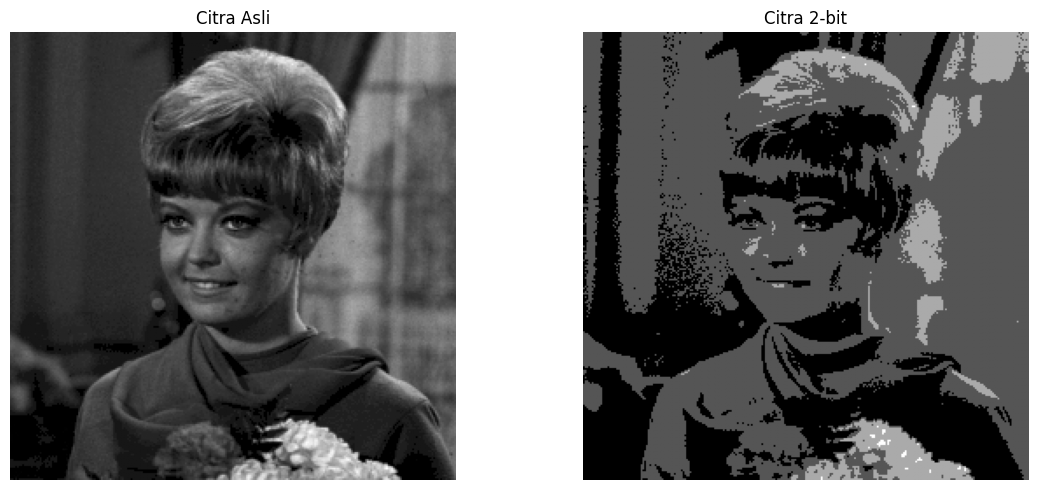

In [19]:
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Tentukan kedalaman bit (contoh: 2-bit = 4 level warna)
bit_depth = 2
level = 255 / (pow(2, bit_depth) - 1)

# Baca gambar dalam mode grayscale
original = cv.imread('/content/drive/MyDrive/PCVK/Images/perempuan.png', cv.IMREAD_GRAYSCALE)

# Cek apakah gambar terbaca
if original is None:
    print("Error: Gambar tidak ditemukan. Cek kembali path file!")
else:
    # Buat array kosong dengan ukuran dan tipe yang sama dengan gambar asli
    depth_image = np.zeros(original.shape, original.dtype)

    # Lakukan proses reduksi bit-depth (kuantisasi)
    for y in range(original.shape[0]):
        for x in range(original.shape[1]):
            value = round(original[y, x] / level) * level
            depth_image[y, x] = np.clip(value, 0, 255)

    # Tampilkan hasil
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Citra Asli')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(depth_image, cmap='gray')
    plt.title(f'Citra {bit_depth}-bit')
    plt.axis('off')

    plt.tight_layout()
    plt.show()



3. Buat modul Average Denoising
Buat modul average denoising sesuai dengan rumus yang telah diberikan pada sub bab
sebelumnya.  
Citra asli sudah disediakan pada /images/galaxy.jpg.
100 Citra dengan Gaussian Noise sudah disediakan pada /images/noises/*.jpg
Anda dapat menggunakan code berikut untuk membaca semua image dalam satu folder ,
gunakan modul glob (import glob).

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Total noisy images: 100
   Jumlah Citra di Average  PSNR (dB)
0                       10      27.55
1                       20      27.51
2                       40      27.46
3                       80      27.40
4                      100      27.36


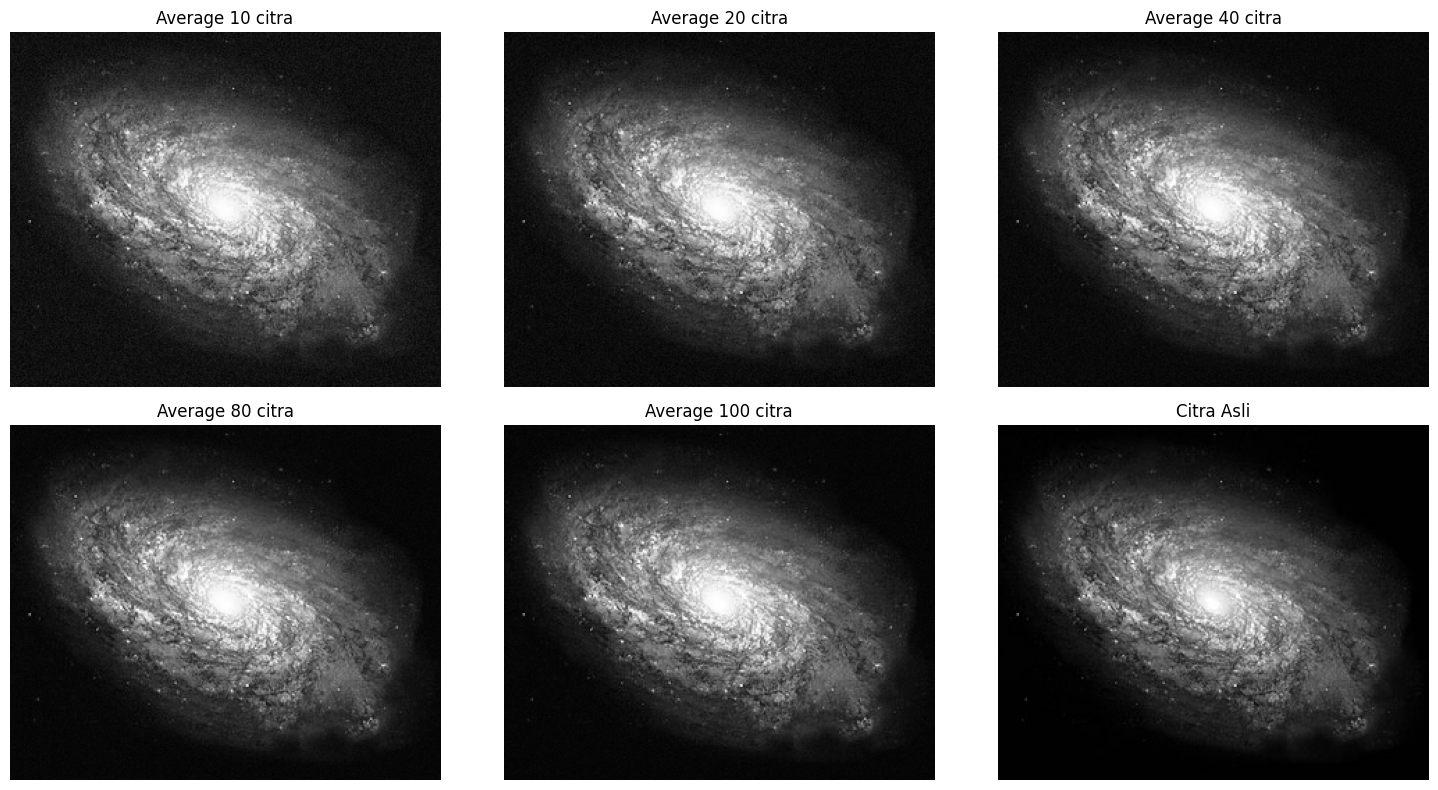

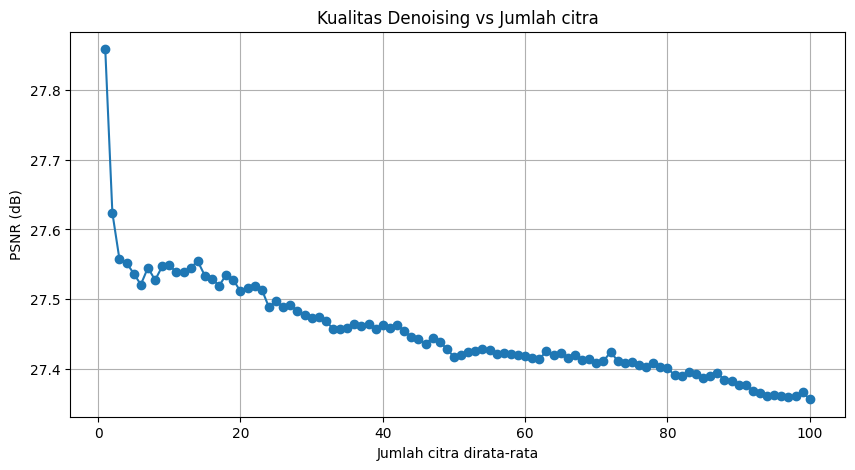

In [23]:

from google.colab import drive
drive.mount('/content/gdrive')

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
import pandas as pd

# Fungsi PSNR
def psnr(original, denoised):
    mse = np.mean((original - denoised) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    return 20 * np.log10(max_pixel / np.sqrt(mse))

#  Baca citra asli (grayscale)
original = cv.imread('/content/gdrive/MyDrive/PCVK/Images/galaxy.jpg', cv.IMREAD_GRAYSCALE)

# Baca salah satu noisy untuk tahu ukuran target
sample_noise = cv.imread('/content/gdrive/MyDrive/PCVK/Images/noises/1.jpg', cv.IMREAD_GRAYSCALE)
h, w = sample_noise.shape

# Resize original agar ukurannya sama dengan noisy
original = cv.resize(original, (w, h))

#  Baca semua citra noisy dan resize ke ukuran yang sama
cv_img = []
for img in glob.glob('/content/gdrive/MyDrive/PCVK/Images/noises/*.jpg'):
    n = cv.imread(img, cv.IMREAD_GRAYSCALE)
    n = cv.resize(n, (w, h))
    cv_img.append(n)

cv_img = np.array(cv_img)
print("Total noisy images:", len(cv_img))

#  Hitung PSNR untuk 1 → N citra
psnr_values = []
for i in range(1, len(cv_img)+1):
    avg = np.mean(cv_img[:i], axis=0)
    avg = np.clip(avg, 0, 255).astype(np.uint8)

    psnr_val = psnr(original, avg)
    psnr_values.append(psnr_val)

#  Buat tabel sesuai soal (10,20,40,80,100)
jumlah = [10, 20, 40, 80, 100]
psnr_selected = [psnr_values[j-1] for j in jumlah]

df = pd.DataFrame({
    "Jumlah Citra di Average": jumlah,
    "PSNR (dB)": [round(val, 2) for val in psnr_selected]
})
print(df)

#  Visualisasi hasil denoising pada jumlah tertentu
jumlah = [10, 20, 40, 80, 100]

plt.figure(figsize=(15, 8))

for i, j in enumerate(jumlah, 1):
    avg_img = np.mean(cv_img[:j], axis=0).astype(np.uint8)
    plt.subplot(2, 3, i)   # grid 2 baris 3 kolom
    plt.imshow(avg_img, cmap='gray')
    plt.title(f"Average {j} citra")
    plt.axis("off")

# tambah citra asli juga biar bisa dibandingkan
plt.subplot(2, 3, 6)
plt.imshow(original, cmap='gray')
plt.title("Citra Asli")
plt.axis("off")

plt.tight_layout()
plt.show()


#  Grafik PSNR
plt.figure(figsize=(10,5))
plt.plot(range(1, len(psnr_values)+1), psnr_values, marker='o')
plt.xlabel("Jumlah citra dirata-rata")
plt.ylabel("PSNR (dB)")
plt.title("Kualitas Denoising vs Jumlah citra")
plt.grid(True)
plt.show()


Dari hasil PSNR diatas, kesimpulan yang dapat saya ambil adalah semakin banyak noise acak yang dirata-ratakan, noise semakin berkurang, metode average efektif untuk mengurangi gaussian noise, namun butuh banyak sample.

4. Buat image masking untuk image berikut. Image kiri adalah image asli (images/couple.tiff),
sedangkan image paling kanan adalah hasilnya:
Lakukan percobaan menggunakan operator lain dan tunjukkan hasilnya pada modul ini.

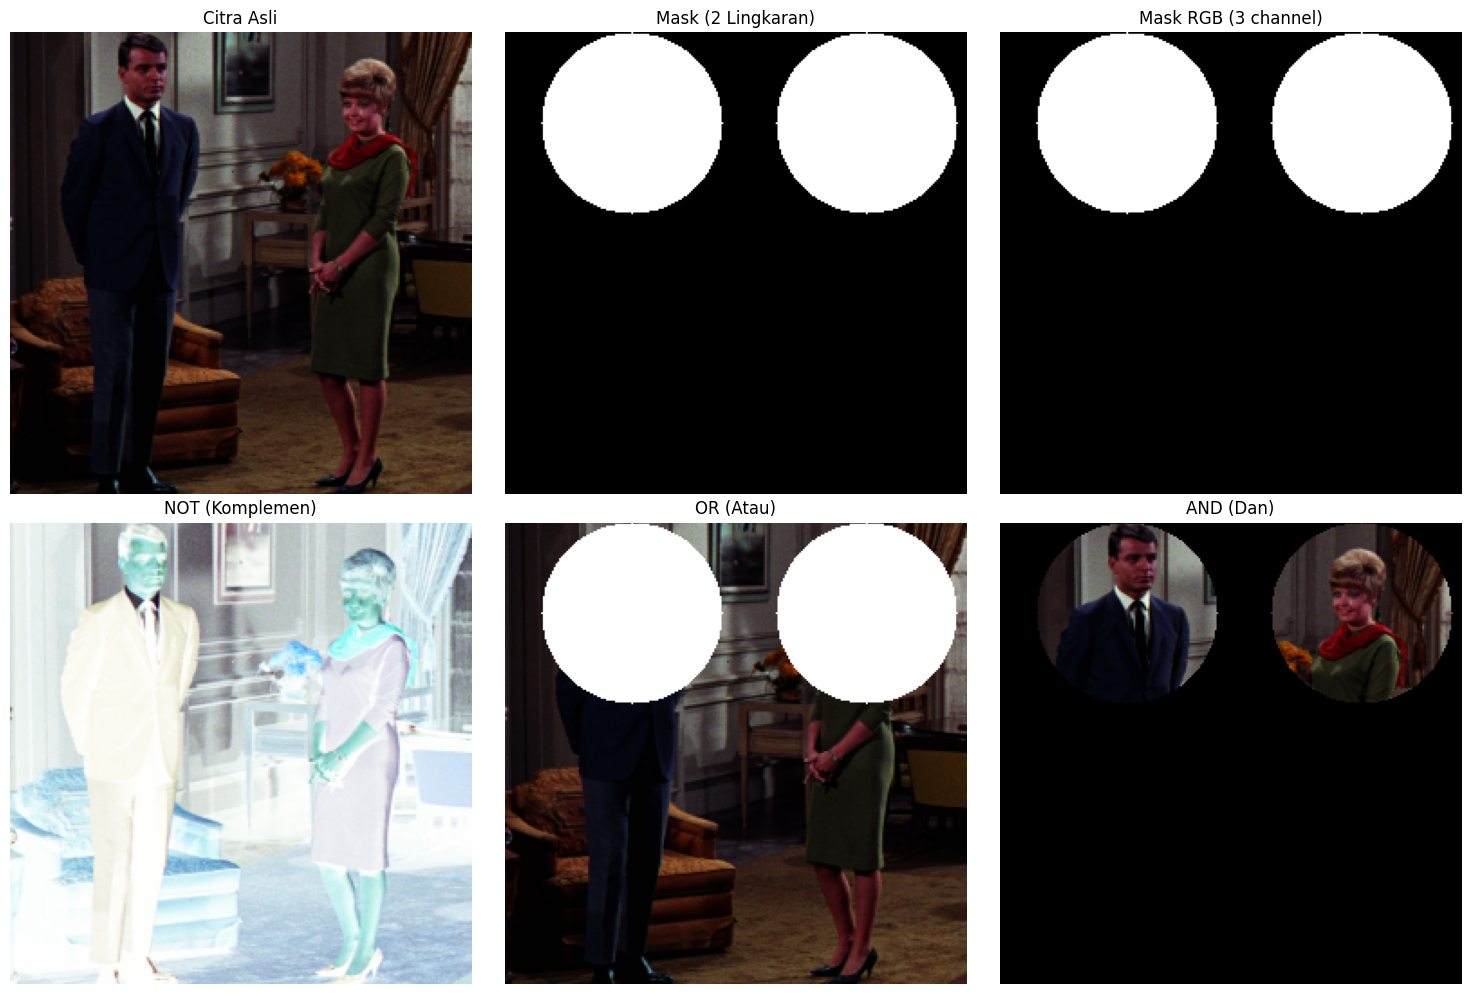

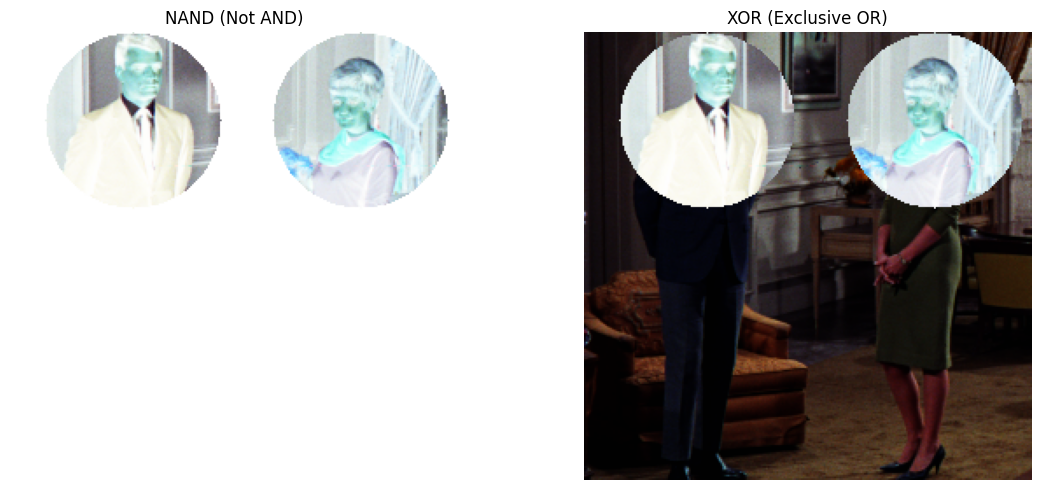

In [24]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


img = cv.imread('/content/gdrive/MyDrive/PCVK/Images/couple.tiff')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Buat mask kosong
mask = np.zeros(img.shape[:2], dtype="uint8")

#  Koordinat lingkaran
circle1 = (70, 50, 50)
circle2 = (200, 50, 50)

# Buat mask (fill putih)
cv.circle(mask, (circle1[0], circle1[1]), circle1[2], 255, -1)
cv.circle(mask, (circle2[0], circle2[1]), circle2[2], 255, -1)

# Konversi mask ke 3 channel biar bisa OR, AND, XOR dengan img (RGB)
mask_rgb = cv.merge([mask, mask, mask])

#  Operator Citra
not_img = cv.bitwise_not(img)                         # NOT pada citra
or_img  = cv.bitwise_or(img, mask_rgb)                # OR
and_img = cv.bitwise_and(img, mask_rgb)               # AND (masking)
nand_img = cv.bitwise_not(and_img)                    # NAND
xor_img = cv.bitwise_xor(img, mask_rgb)               # XOR

#  Visualisasi
plt.figure(figsize=(15,10))

# Input
plt.subplot(2,3,1)
plt.imshow(img)
plt.title("Citra Asli")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask (2 Lingkaran)")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(mask_rgb)
plt.title("Mask RGB (3 channel)")
plt.axis("off")

# Output
plt.subplot(2,3,4)
plt.imshow(not_img)
plt.title("NOT (Komplemen)")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(or_img)
plt.title("OR (Atau)")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(and_img)
plt.title("AND (Dan)")
plt.axis("off")

plt.tight_layout()
plt.show()

# NAND & XOR
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(nand_img)
plt.title("NAND (Not AND)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(xor_img)
plt.title("XOR (Exclusive OR)")
plt.axis("off")

plt.tight_layout()
plt.show()

Tuliskan hasil analisa anda kenapa citra keluarannya seperti itu.

## 1. Citra Asli (img) <br>
Merupakan gambar awal berwarna (RGB) yang dibaca dari file couple.tiff. <br>
Semua operasi berikutnya dilakukan berdasarkan nilai piksel gambar ini. <br>
Nilai piksel tiap channel (R, G, B) berada pada rentang 0–255. <br>

## 2. Mask (2 Lingkaran) <br>
Mask awalnya berupa gambar hitam semua (nilai 0) → artinya tidak ada area yang aktif. <br>
Kemudian dibuat dua lingkaran putih (nilai 255) di dalamnya. <br>
Area putih inilah yang akan menjadi area aktif pada proses masking. <br>
Hasilnya adalah gambar hitam-putih dengan dua lingkaran putih di atas latar hitam. <br>

## 3. Mask RGB <br>

Karena gambar asli (img) memiliki 3 channel warna (R, G, B), maka mask juga diubah menjadi 3 channel dengan cara:
mask_rgb = cv.merge([mask, mask, mask]) <br>
Tujuannya supaya mask bisa digunakan untuk operasi logika piksel terhadap citra RGB. <br>

## 4.Operator Bitwise
**a. NOT (Komplemen)**

not_img = cv.bitwise_not(img) <br>
Setiap piksel p akan diubah menjadi 255 - p. <br>
Piksel terang menjadi gelap, dan sebaliknya. <br>
Hasilnya: gambar tampak seperti negatif film kamera (warna kebalikan). <br>
Contoh: biru muda jadi oranye, putih jadi hitam. <br>
Analisis: <br>
NOT membalik setiap bit (0→1, 1→0). Karena tiap channel 8-bit, maka [R,G,B] berubah menjadi [255-R, 255-G, 255-B]. <br>

**b. OR (Atau) <br>**
Karena mask berisi 255 (putih) di area lingkaran → hasil OR di area tersebut akan menjadi 255 (terang). <br>
Di luar lingkaran (mask = 0), nilai piksel tetap seperti gambar asli. <br>
Analisis: <br>
Dua lingkaran jadi putih terang, sedangkan area lainnya tetap seperti citra awal. <br>
Efeknya seperti menambahkan cahaya putih di dua area lingkaran. <br>

**c. AND (Dan)<br>**
Hanya area yang bernilai putih (255) pada mask yang akan “dilewatkan”. <br>
Di luar area lingkaran (mask hitam), hasilnya hitam total. <br>
Analisis: <br>
Citra hasilnya tampak seperti dua lingkaran yang memperlihatkan bagian gambar asli, sedangkan area lainnya hitam. <br>

**d. NAND (Not AND)<br>**
NAND adalah kebalikan dari AND. <br>
Area yang tadinya menampilkan gambar (lingkaran) jadi gelap, sedangkan area lain jadi terang. <br>
Analisis: <br>
Karena AND dibalik dengan NOT, maka lingkaran (yang sebelumnya terlihat) menjadi hitam, dan latar belakangnya menjadi kebalikan dari warna aslinya. <br>

**e. XOR (Exclusive OR)<br>**
Artinya hanya area yang berbeda antara img dan mask_rgb yang akan muncul. <br>
Karena mask putih di area lingkaran, maka di area tersebut warna gambar akan berubah (terbalik sebagian). <br>
Analisis: <br>
Dua lingkaran tampak seperti efek warna terbalik/glowing, sedangkan area lain tetap seperti gambar asli. <br>